In [1]:
import marcrypto as mc
import numpy as np
import matplotlib.pylab as plt

In [2]:
rng = mc.random.rng_sv()

In [24]:
rng_pcg64 = mc.random.rng_pcg64()

In [3]:
%timeit u = rng.next_u64()

297 ns ± 0.294 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [8]:
%timeit u = rng.next_f64()

298 ns ± 0.499 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [5]:
%timeit u = rng.next_f32()

317 ns ± 0.562 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [6]:
%timeit x = np.random.randint(10)

1.3 µs ± 1.97 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [7]:
%timeit x = np.random.rand()

198 ns ± 0.219 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [21]:
for _ in range(10):
    print(rng.choice(['a', 'b', 'c'], [0.2, 0.3, 0.5]))

b
b
b
c
b
c
c
c
b
a


In [14]:
samples = np.array([rng.norm() for x in range(100000)])

In [15]:
np.mean(samples), np.std(samples)

(0.000310320694155244, 2.523029923293449)

(array([ 2065.,  4898.,  8911., 18048., 16183., 15747., 18093.,  9028.,
         4941.,  2086.]),
 array([-6.33734502e+00, -5.07065156e+00, -3.80395811e+00, -2.53726465e+00,
        -1.27057119e+00, -3.87773808e-03,  1.26281572e+00,  2.52950917e+00,
         3.79620263e+00,  5.06289609e+00,  6.32958954e+00]),
 <BarContainer object of 10 artists>)

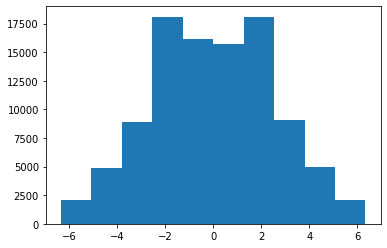

In [16]:
plt.hist(samples)

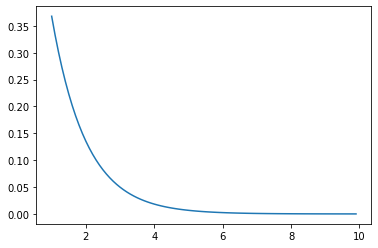

In [20]:
x = np.arange(1, 10, 0.1)
y = np.exp(-x)
plt.plot(x, y)

In [43]:
def make_probs_slot(step = 0.0001):
    intervals = np.arange(0, 20.0, step)
    probs = []
    for i in range(len(intervals)):
        p0 = np.exp(-i*step)
        p1 = np.exp(-(i+1)*step)
        p = p0 - p1
        probs.append(p)
    
    probs = np.array(probs)
    adjust_weight = 1.0/sum(probs)
    probs *= adjust_weight
    
    return intervals, probs

In [56]:
intervals, probs = make_probs_slot(step=0.01)
print(sum(probs))

0.9999999999999986


In [50]:
for i in range(10):
    print(f"{rng.choice_idx(probs)}")

651
34834
8763
1015
1771
5382
7616
1413
106
1443


In [66]:
%time sample_indices = [rng.choice_idx(probs) for _ in range(100000)]

CPU times: user 28.4 s, sys: 186 ms, total: 28.6 s
Wall time: 28.7 s


In [61]:
samples = intervals[sample_indices]

(array([9.455e+03, 8.485e+03, 8.491e+03, 6.230e+03, 6.360e+03, 6.422e+03,
        4.599e+03, 4.766e+03, 4.350e+03, 3.930e+03, 3.468e+03, 3.484e+03,
        2.532e+03, 2.688e+03, 2.340e+03, 2.071e+03, 2.069e+03, 1.639e+03,
        1.554e+03, 1.413e+03, 1.299e+03, 1.218e+03, 1.067e+03, 1.104e+03,
        7.750e+02, 8.170e+02, 7.300e+02, 6.470e+02, 6.520e+02, 4.440e+02,
        4.940e+02, 3.990e+02, 3.790e+02, 3.770e+02, 2.890e+02, 2.790e+02,
        2.460e+02, 2.400e+02, 2.120e+02, 1.680e+02, 1.810e+02, 1.290e+02,
        1.540e+02, 1.490e+02, 1.140e+02, 9.600e+01, 7.700e+01, 1.030e+02,
        6.400e+01, 6.000e+01, 5.800e+01, 6.100e+01, 5.400e+01, 4.100e+01,
        4.900e+01, 4.200e+01, 4.100e+01, 2.900e+01, 2.900e+01, 3.500e+01,
        2.600e+01, 2.200e+01, 2.300e+01, 1.900e+01, 2.100e+01, 1.400e+01,
        1.800e+01, 1.400e+01, 1.200e+01, 9.000e+00, 6.000e+00, 1.000e+00,
        1.200e+01, 6.000e+00, 7.000e+00, 2.000e+00, 3.000e+00, 7.000e+00,
        3.000e+00, 2.000e+00, 2.000e+0

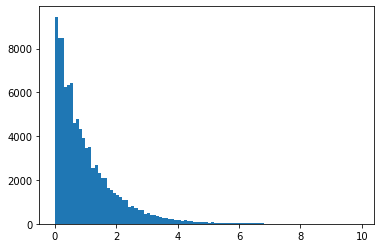

In [65]:
plt.hist(samples, bins=np.arange(0, 10, 0.1))

In [67]:
%time sample_indices = [rng.choice_idx(probs) for _ in range(500000)]

CPU times: user 2min 21s, sys: 543 ms, total: 2min 22s
Wall time: 2min 22s


In [68]:
samples = intervals[sample_indices]

(array([4.7570e+04, 4.3108e+04, 4.2703e+04, 3.1270e+04, 3.2112e+04,
        3.1386e+04, 2.3241e+04, 2.3717e+04, 2.1417e+04, 1.9418e+04,
        1.7840e+04, 1.7234e+04, 1.2936e+04, 1.3039e+04, 1.1710e+04,
        1.0481e+04, 1.0395e+04, 7.8000e+03, 7.7500e+03, 7.2580e+03,
        6.3020e+03, 5.7340e+03, 5.3380e+03, 5.2570e+03, 3.9240e+03,
        3.9100e+03, 3.5510e+03, 3.2800e+03, 3.1140e+03, 2.3950e+03,
        2.3590e+03, 2.1420e+03, 1.9710e+03, 1.9600e+03, 1.3740e+03,
        1.4400e+03, 1.3360e+03, 1.2040e+03, 1.1210e+03, 8.7100e+02,
        9.5600e+02, 6.7900e+02, 7.0400e+02, 6.1000e+02, 5.7800e+02,
        5.1200e+02, 4.7300e+02, 4.6100e+02, 3.4600e+02, 3.7200e+02,
        3.4000e+02, 3.0700e+02, 3.0700e+02, 1.8000e+02, 2.0000e+02,
        2.0300e+02, 1.8400e+02, 1.4500e+02, 1.2400e+02, 1.3300e+02,
        1.1800e+02, 1.0300e+02, 9.7000e+01, 7.1000e+01, 7.3000e+01,
        6.2000e+01, 5.3000e+01, 5.7000e+01, 5.4000e+01, 5.8000e+01,
        6.4000e+01, 3.8000e+01, 4.3000e+01, 3.30

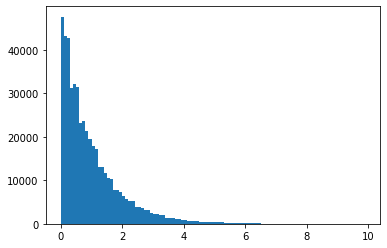

In [69]:
plt.hist(samples, bins=np.arange(0, 10, 0.1))

In [71]:
len(samples)

500000

In [4]:
%timeit x = rng.next_neg_exp()

32.5 µs ± 125 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [11]:
%time samples = [rng.next_neg_exp() for _ in range(1000000)]

CPU times: user 32.3 s, sys: 66.8 ms, total: 32.4 s
Wall time: 32.4 s


(array([9.5252e+04, 8.5801e+04, 8.4945e+04, 6.3110e+04, 6.3731e+04,
        6.3109e+04, 5.1972e+04, 4.2410e+04, 4.2761e+04, 3.8808e+04,
        3.4708e+04, 3.4511e+04, 2.5760e+04, 2.8533e+04, 2.1051e+04,
        2.1075e+04, 2.1108e+04, 1.5779e+04, 1.7177e+04, 1.2714e+04,
        1.2747e+04, 1.1408e+04, 1.1543e+04, 9.5740e+03, 7.8540e+03,
        7.9370e+03, 7.0930e+03, 7.0520e+03, 5.7160e+03, 4.7150e+03,
        4.8720e+03, 4.1700e+03, 4.1870e+03, 3.5100e+03, 2.9400e+03,
        2.9000e+03, 2.6680e+03, 2.6470e+03, 2.0540e+03, 1.7990e+03,
        1.9070e+03, 1.4050e+03, 1.3450e+03, 1.2860e+03, 1.1910e+03,
        1.1210e+03, 8.3100e+02, 9.1100e+02, 6.8500e+02, 7.4300e+02,
        7.3300e+02, 5.5000e+02, 5.9500e+02, 4.5000e+02, 4.6300e+02,
        4.4500e+02, 2.9100e+02, 3.2400e+02, 2.7500e+02, 2.6900e+02,
        2.4000e+02, 2.2200e+02, 1.8700e+02, 1.5300e+02, 1.7900e+02,
        1.6200e+02, 1.1900e+02, 1.0700e+02, 9.8000e+01, 1.0200e+02,
        1.0700e+02, 6.5000e+01, 6.7000e+01, 7.10

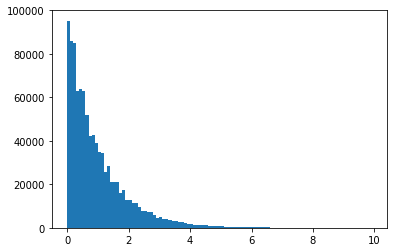

In [12]:
plt.hist(samples, bins=np.arange(0, 10, 0.1))

In [10]:
%time norm_samples = [rng.norm() for _ in range(5000000)]

CPU times: user 1.93 s, sys: 36.1 ms, total: 1.96 s
Wall time: 1.96 s


In [11]:
np.mean(norm_samples), np.std(norm_samples)

(0.0006201967517083175, 1.0000084464040553)

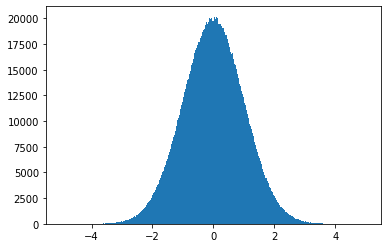

In [30]:
_ = plt.hist(norm_samples, bins=np.arange(-5, 5, 0.01))

In [19]:
%time norm_samples_np = [np.random.normal() for _ in range(5000000)]

CPU times: user 2.51 s, sys: 46.8 ms, total: 2.55 s
Wall time: 2.56 s


In [20]:
np.mean(norm_samples_np), np.std(norm_samples_np)

(0.00014510914256672262, 1.0002276984000027)

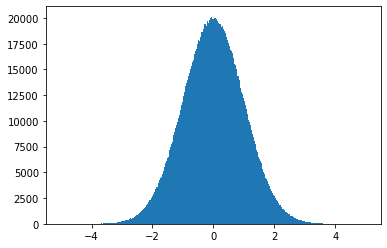

In [29]:
_ = plt.hist(norm_samples_np, bins=np.arange(-5, 5, 0.01))

In [25]:
%time norm_samples_pcg64 = [rng_pcg64.norm() for _ in range(5000000)]

CPU times: user 1.92 s, sys: 34.3 ms, total: 1.96 s
Wall time: 1.96 s


In [26]:
np.mean(norm_samples_pcg64), np.std(norm_samples_pcg64)

(0.00029258319285241434, 1.000197315093478)

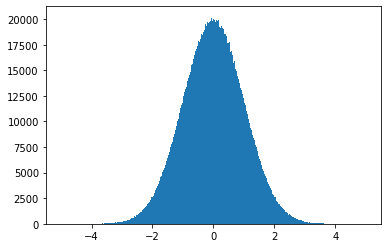

In [28]:
_ = plt.hist(norm_samples_pcg64, bins=np.arange(-5, 5, 0.01))